In [0]:
from pyspark.sql.functions import col

# --------------------------------
# SILVER LAYER
# --------------------------------

# Bronze Delta path
bronze_path = "/Volumes/etlpipelineincome/default/bronze/raw_income"

# Silver output path
silver_path = "/Volumes/etlpipelineincome/default/bronze/silver/clean_income"

# Read Bronze Delta
df_silver = spark.read \
    .format("delta") \
    .load(bronze_path)

# Remove duplicate rows
df_silver = df_silver.dropDuplicates()

# Remove rows containing NULL values
df_silver = df_silver.dropna()

# Show cleaned data
df_silver.show(10)

# Check schema
df_silver.printSchema()

# Save Silver as Delta
df_silver.write \
    .format("delta") \
    .mode("overwrite") \
    .save(silver_path)

print("Silver layer created successfully")

+----------+------+-------------+
|CustomerID|Income|SpendingScore|
+----------+------+-------------+
|        19| 36023|           20|
|        29| 25311|           14|
|        53| 76886|           41|
|        66| 28792|           12|
|        68|128557|           29|
|        78| 43483|           37|
|        84|126530|           48|
|       110| 31534|           18|
|       149| 33986|           27|
|       158| 72251|           43|
+----------+------+-------------+
only showing top 10 rows
root
 |-- CustomerID: integer (nullable = true)
 |-- Income: integer (nullable = true)
 |-- SpendingScore: integer (nullable = true)

Silver layer created successfully


In [0]:
df_silver.columns

['CustomerID', 'Income', 'SpendingScore']

In [0]:
# Delete old Silver Delta table
dbutils.fs.rm(
    "/Volumes/etlpipelineincome/default/bronze/silver/clean_income",
    True
)

print("Old Silver table deleted")

Old Silver table deleted


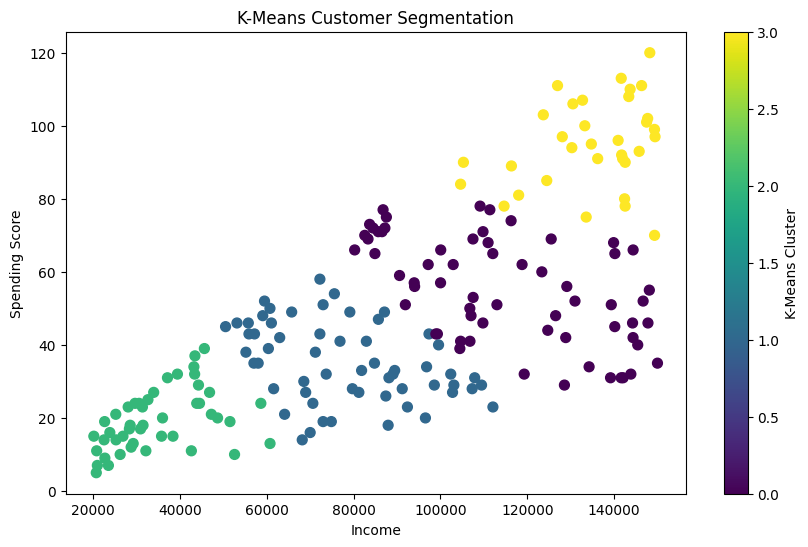

+----------+------+-------------+--------------+
|CustomerID|Income|SpendingScore|KMeans_Cluster|
+----------+------+-------------+--------------+
|        19| 36023|           20|             2|
|        29| 25311|           14|             2|
|        53| 76886|           41|             1|
|        66| 28792|           12|             2|
|        68|128557|           29|             0|
|        78| 43483|           37|             2|
|        84|126530|           48|             0|
|       110| 31534|           18|             2|
|       149| 33986|           27|             2|
|       158| 72251|           43|             1|
|       161| 50535|           45|             1|
|       200| 70015|           16|             1|
|        18| 80263|           66|             0|
|        28| 87969|           18|             1|
|        35| 48693|           20|             2|
|        49|104654|           41|             0|
|        69| 93969|           57|             0|
|        74|141729| 

In [0]:
from pyspark.ml.feature import VectorAssembler, StandardScaler
from pyspark.ml.clustering import KMeans

# --------------------------------
# PATHS
# --------------------------------

bronze_path = "/Volumes/etlpipelineincome/default/bronze/raw_income"

silver_path = "/Volumes/etlpipelineincome/default/bronze/silver/clean_income"

# --------------------------------
# 1. READ BRONZE
# --------------------------------

df_silver = spark.read \
    .format("delta") \
    .load(bronze_path)

# --------------------------------
# 2. CLEAN DATA
# --------------------------------

df_silver = df_silver.dropDuplicates()

df_silver = df_silver.dropna()

# --------------------------------
# 3. CREATE FEATURES
# --------------------------------

assembler = VectorAssembler(
    inputCols=["Income", "SpendingScore"],
    outputCol="features"
)

df_silver = assembler.transform(df_silver)

# --------------------------------
# 4. SCALE FEATURES
# --------------------------------

scaler = StandardScaler(
    inputCol="features",
    outputCol="scaled_features",
    withMean=True,
    withStd=True
)

scaler_model = scaler.fit(df_silver)

df_silver = scaler_model.transform(df_silver)

# --------------------------------
# 5. K-MEANS
# --------------------------------

kmeans = KMeans(
    k=4,
    seed=42,
    featuresCol="scaled_features",
    predictionCol="KMeans_Cluster"
)

kmeans_model = kmeans.fit(df_silver)

df_silver = kmeans_model.transform(df_silver)

import matplotlib.pyplot as plt

# Convert required columns to Pandas
plot_df = df_silver.select(
    "Income",
    "SpendingScore",
    "KMeans_Cluster"
).toPandas()

# Scatter plot
plt.figure(figsize=(10, 6))

plt.scatter(
    plot_df["Income"],
    plot_df["SpendingScore"],
    c=plot_df["KMeans_Cluster"],
    s=50
)

plt.xlabel("Income")
plt.ylabel("Spending Score")
plt.title("K-Means Customer Segmentation")
plt.colorbar(label="K-Means Cluster")

plt.show()

# --------------------------------
# 6. VIEW RESULT
# --------------------------------

df_silver.select(
    "CustomerID",
    "Income",
    "SpendingScore",
    "KMeans_Cluster"
).show(20)

# --------------------------------
# 7. SAVE SILVER
# --------------------------------

df_silver.write \
    .format("delta") \
    .mode("overwrite") \
    .save(silver_path)

print("Silver layer with K-Means created successfully")